# Flight Delay & Operational Performance Analysis

## Project Objective

In this project, flight operations data is analyzed using Python (Pandas) to understand flight delays, operational patterns, and performance trends. The goal is to identify delay trends, on-time performance, and operational insights through data analysis and visualizations.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
flights = pd.read_csv("Flight_Operations_Delay_500Rows.csv")

# Display first 5 rows
flights.head()

,Flight_ID,Airline,Origin_Airport,Destination_Airport,Scheduled_Departure,Actual_Departure,Delay_Minutes,Flight_Status,Flight_Duration_Minutes,Month,Day_of_Week,Departure_Hour
0,FL1000,Go First,BOM,DEL,2025-04-04 21:00,2025-04-04 21:38,38,Delayed,122,Apr,Friday,21
1,FL1001,Go First,BOM,PNQ,2025-01-30 16:00,2025-01-30 16:24,24,Delayed,211,Jan,Thursday,16
2,FL1002,IndiGo,BOM,BLR,2025-03-21 09:00,2025-03-21 09:42,42,Delayed,189,Mar,Friday,9
3,FL1003,Akasa Air,HYD,PNQ,2025-05-24 04:00,2025-05-24 05:01,61,Delayed,116,May,Saturday,4
4,FL1004,SpiceJet,DEL,AMD,2025-02-24 11:00,2025-02-24 11:22,22,Delayed,168,Feb,Monday,11


## Data Understanding

The dataset contains flight operation records including airlines, airports, departure timings, delay minutes, operational status, and scheduling information. The analysis focuses on identifying operational trends, delay behavior, and performance insights.


In [ ]:
# Dataset shape
print("Rows and Columns:", flights.shape)

# Column information
flights.info()

# Statistical summary
flights.describe()

Rows and Columns: (500, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Flight_ID                500 non-null    object
 1   Airline                  500 non-null    object
 2   Origin_Airport           500 non-null    object
 3   Destination_Airport      500 non-null    object
 4   Scheduled_Departure      500 non-null    object
 5   Actual_Departure         500 non-null    object
 6   Delay_Minutes            500 non-null    int64 
 7   Flight_Status            500 non-null    object
 8   Flight_Duration_Minutes  500 non-null    int64 
 9   Month                    500 non-null    object
 10  Day_of_Week              500 non-null    object
 11  Departure_Hour           500 non-null    int64 
dtypes: int64(3), object(9)
memory usage: 47.0+ KB


,Delay_Minutes,Flight_Duration_Minutes,Departure_Hour
count,500.000000,500.000000,500.000000
mean,27.736000,144.968000,11.882000
std,20.342417,45.765488,6.984672
min,0.000000,60.000000,0.000000
25%,11.000000,105.000000,6.000000
50%,27.000000,148.000000,12.000000
75%,41.000000,183.000000,18.000000
max,112.000000,220.000000,23.000000


## Data Cleaning

The dataset was checked for missing values, converted into appropriate formats, and prepared for delay analysis.


In [ ]:
# Missing values
flights.isnull().sum()

,0
Flight_ID,0
Airline,0
Origin_Airport,0
Destination_Airport,0
Scheduled_Departure,0
Actual_Departure,0
Delay_Minutes,0
Flight_Status,0
Flight_Duration_Minutes,0
Month,0


In [ ]:
# Convert datetime columns
flights["Scheduled_Departure"] = pd.to_datetime(flights["Scheduled_Departure"])

flights["Actual_Departure"] = pd.to_datetime(flights["Actual_Departure"])

# Check data types
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Flight_ID                500 non-null    object        
 1   Airline                  500 non-null    object        
 2   Origin_Airport           500 non-null    object        
 3   Destination_Airport      500 non-null    object        
 4   Scheduled_Departure      500 non-null    datetime64[ns]
 5   Actual_Departure         500 non-null    datetime64[ns]
 6   Delay_Minutes            500 non-null    int64         
 7   Flight_Status            500 non-null    object        
 8   Flight_Duration_Minutes  500 non-null    int64         
 9   Month                    500 non-null    object        
 10  Day_of_Week              500 non-null    object        
 11  Departure_Hour           500 non-null    int64         
dtypes: datetime64[ns](2), int64(3), obje

## Feature Engineering

New columns created to improve analysis and better understand delay performance. This includes identifying delayed flights and grouping delays into categories.


In [ ]:
# Delayed flight flag
flights["Is_Delayed"] = flights["Delay_Minutes"] > 15

# Delay category
def delay_category(delay):
    if delay == 0:
        return "On Time"
    elif delay <= 30:
        return "Short Delay"
    elif delay <= 60:
        return "Moderate Delay"
    else:
        return "Severe Delay"

flights["Delay_Category"] = flights["Delay_Minutes"].apply(delay_category)

# Display sample
flights.head()

,Flight_ID,Airline,Origin_Airport,Destination_Airport,Scheduled_Departure,Actual_Departure,Delay_Minutes,Flight_Status,Flight_Duration_Minutes,Month,Day_of_Week,Departure_Hour,Is_Delayed,Delay_Category
0,FL1000,Go First,BOM,DEL,2025-04-04 21:00:00,2025-04-04 21:38:00,38,Delayed,122,Apr,Friday,21,True,Moderate Delay
1,FL1001,Go First,BOM,PNQ,2025-01-30 16:00:00,2025-01-30 16:24:00,24,Delayed,211,Jan,Thursday,16,True,Short Delay
2,FL1002,IndiGo,BOM,BLR,2025-03-21 09:00:00,2025-03-21 09:42:00,42,Delayed,189,Mar,Friday,9,True,Moderate Delay
3,FL1003,Akasa Air,HYD,PNQ,2025-05-24 04:00:00,2025-05-24 05:01:00,61,Delayed,116,May,Saturday,4,True,Severe Delay
4,FL1004,SpiceJet,DEL,AMD,2025-02-24 11:00:00,2025-02-24 11:22:00,22,Delayed,168,Feb,Monday,11,True,Short Delay


## Operational KPI Analysis

Basic operational KPIs were analyzed to understand flight performance, delay frequency, and overall operational trends.

In [ ]:
# Total flights
total_flights = len(flights)

# Delayed flights
delayed_flights = flights["Is_Delayed"].sum()

# On-time flights
on_time_flights = total_flights - delayed_flights

# Average delay
average_delay = flights["Delay_Minutes"].mean()

# Maximum delay
max_delay = flights["Delay_Minutes"].max()

# On-time percentage
on_time_percentage = (
    on_time_flights / total_flights
) * 100

# Print KPIs
print("Total Flights:", total_flights)
print("Delayed Flights:", delayed_flights)
print("On-Time Flights:", on_time_flights)
print("Average Delay (minutes):",round(average_delay, 2))
print("Maximum Delay (minutes):",max_delay)
print("On-Time Percentage:",round(on_time_percentage, 2), "%")

Total Flights: 500
Delayed Flights: 339
On-Time Flights: 161
Average Delay (minutes): 27.74
Maximum Delay (minutes): 112
On-Time Percentage: 32.2 %


## Delay Trend Analysis

Delay trends analyzed to identify patterns across weekdays, airlines, and delay categories.

In [ ]:
# Average delay by day of week
weekday_delay = flights.groupby("Day_of_Week")["Delay_Minutes"].mean()

weekday_delay

,Delay_Minutes
Day_of_Week,
Friday,28.744186
Monday,28.675325
Saturday,28.341463
Sunday,21.679245
Thursday,30.388889
Tuesday,28.671642
Wednesday,25.492063


In [ ]:
# Average delay by airline
airline_delay = flights.groupby("Airline")["Delay_Minutes"].mean()

airline_delay

,Delay_Minutes
Airline,
Air India,29.716049
Akasa Air,28.712871
Go First,25.573171
IndiGo,27.391892
SpiceJet,27.126437
Vistara,27.693333


In [ ]:
# Delay category distribution
delay_category_count = flights["Delay_Category"].value_counts()

delay_category_count

,count
Delay_Category,
Short Delay,221
Moderate Delay,183
On Time,62
Severe Delay,34


### Delay Pattern by Day of Week

This chart shows the average delay time across weekdays to understand when delays are more common.

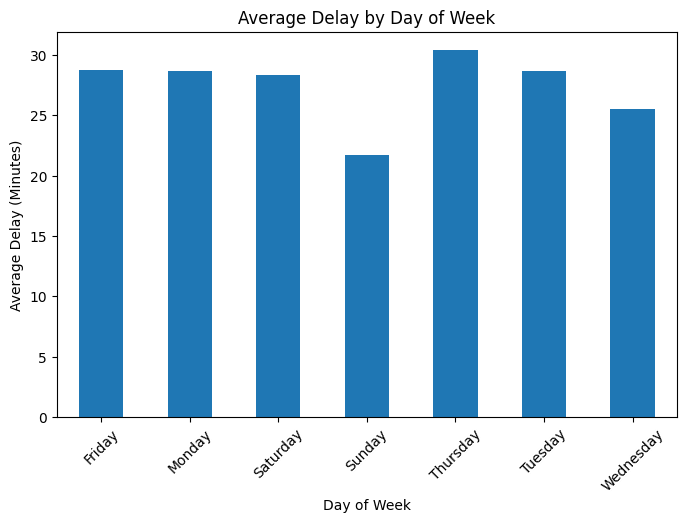

In [ ]:
plt.figure(figsize=(8,5))

weekday_delay.plot(kind="bar")

plt.title("Average Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)

plt.show()

### Delay Performance by Airline

This chart compares average flight delays across airlines to understand operational performance differences.

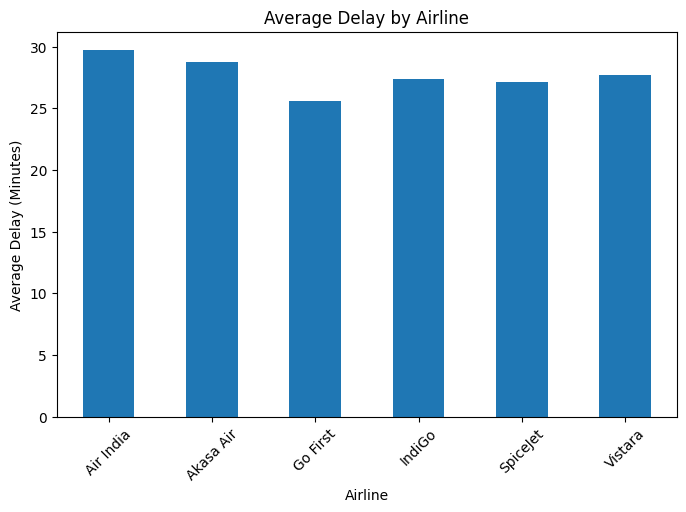

In [ ]:
plt.figure(figsize=(8,5))

airline_delay.plot(kind="bar")

plt.title("Average Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)

plt.show()

### Delay Category Distribution

This chart shows the distribution of flights based on delay severity.

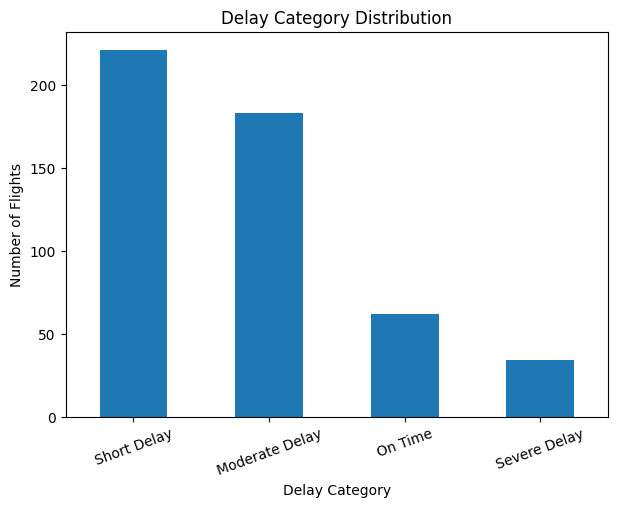

In [ ]:
plt.figure(figsize=(7,5))

delay_category_count.plot(
    kind="bar"
)

plt.title("Delay Category Distribution")
plt.xlabel("Delay Category")
plt.ylabel("Number of Flights")
plt.xticks(rotation=20)

plt.show()

In [ ]:
# For Flight Status Distribution

flight_status = flights["Flight_Status"].value_counts()

flight_status

,count
Flight_Status,
Delayed,339
On Time,148
Cancelled,13


### Flight Status Distribution

This chart shows the number of on-time, delayed, and cancelled flights in the dataset.

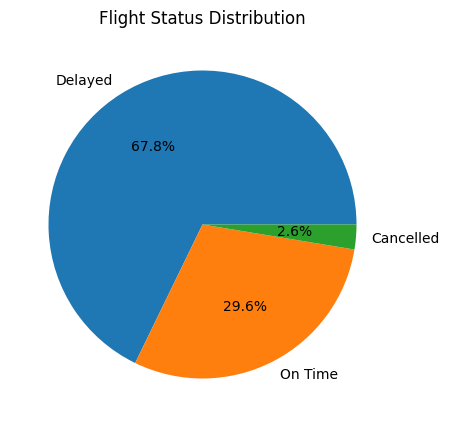

In [ ]:
plt.figure(figsize=(7,5))

flight_status.plot(kind="pie",autopct="%1.1f%%")

plt.title("Flight Status Distribution")

plt.ylabel("")

plt.show()

## Business Insights

The analysis helped understand flight delays and overall flight performance.

### Key Insights

1. Flight delays were different across weekdays, showing that some days had more delays than others.

2. Delay time was different across airlines, showing changes in flight performance.

3. Most flights had short or medium delays, while long delays happened less often.

4. The dataset included on-time, delayed, and cancelled flights, showing different operational situations.

5. Delay analysis can help track flight performance and improve operational monitoring.

## Conclusion

This project used Python (Pandas) to analyze flight delays and flight performance. The analysis included data cleaning, delay categories, KPI analysis, trend analysis, and charts to better understand flight operations.